In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [4]:
from package.model_deep_ae_20250829 import (set_seed,
                                generate_mock_data,
                                expand_rule_columns,
                                subset_by_timeunit,
                                split_train_test,
                                )

# Read Data

In [5]:
mock1 = generate_mock_data(n_sales=10000, n_rules=10, fraud_ratio=0.05, seed=42)
mock1

function: generate_mock_data is starting...
function: generate_mock_data successfully executed at 1.9082024097442627s


,sales_id,expected_dt,timeunit,flag_fraud,rule_1,rule_2,rule_3,rule_4,rule_5,rule_6,rule_7,rule_8,rule_9,rule_10
0,0,2024-12-30,l3,0,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581,-0.771890
1,1,2024-07-14,l3,1,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348,1.960721
2,2,2025-05-26,l3,0,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390,0.406085
3,3,2025-05-25,l3,0,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432,0.339529
4,4,2025-06-17,l3,0,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522,0.081125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9995,2024-07-01,l36,0,-1.393785,1.119496,-2.225198,0.355354,-1.114918,-0.348127,0.696269,-1.856022,-0.773980,-1.019967
59996,9996,2025-05-03,l36,0,1.914040,-0.250864,-0.670143,0.249901,-0.351280,-0.121383,0.274123,-0.559135,-0.084692,0.955931
59997,9997,2024-10-22,l36,0,0.580123,-0.555800,0.536215,-0.590000,-1.563657,0.052191,0.271158,-0.696574,-1.674949,-1.058655
59998,9998,2024-11-24,l36,0,1.381821,-0.886731,-0.431143,0.390082,0.668774,-1.953408,-0.687125,-1.467512,-0.240759,0.654136


In [6]:
df_transformed = expand_rule_columns(mock1)
df_transformed

function: expand_rule_columns is starting...
function: expand_rule_columns successfully executed at 0.6067345142364502s


,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0,2024-12-30,0,1.294071,-0.033099,-0.771890,1.027978,-1.716319,-0.438359,-0.844588,...,-0.977754,-1.817574,-1.378777,-0.720249,-0.153002,0.147629,-0.051581,-1.928613,-1.005889,-1.700068
1,1,2024-07-14,1,2.970241,1.546394,1.960721,0.327022,1.395264,2.302689,2.134491,...,3.658322,2.169982,4.625339,4.100241,5.391337,4.974683,2.477348,5.201170,0.888200,0.345258
2,2,2025-05-26,0,-0.962456,0.007673,0.406085,-0.324495,-0.351193,-0.073130,-1.225513,...,1.040642,-0.017216,3.053033,1.115441,-2.003674,-0.515232,0.347390,1.687974,-0.886053,0.373724
3,3,2025-05-25,0,-0.557176,0.152205,0.339529,0.084018,0.929277,0.426988,0.121433,...,-0.063098,1.076034,-0.388208,1.075950,-0.600473,-2.693087,0.062432,-0.566217,0.786089,1.194925
4,4,2025-06-17,0,-0.822350,-0.840434,0.081125,-0.962901,-0.471622,-0.433285,1.266659,...,0.140467,-1.761751,-0.281367,1.718366,0.989666,-0.659094,-1.124522,-0.808209,-1.347342,0.004178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,1.743071,-0.215017,-0.953072,-1.019967,-0.682181,1.137971,-0.507696,...,-0.945883,-1.856022,-1.172909,0.589566,0.158376,0.376485,-1.294563,-0.773980,0.137205,-0.786161
9996,9996,2025-05-03,0,0.185918,0.366925,-0.035507,0.955931,-0.901071,-0.267223,-1.110620,...,0.152714,-0.559135,-0.246215,0.267680,-0.556548,1.367107,0.888219,-0.084692,-0.196889,-2.770211
9997,9997,2024-10-22,0,-1.890159,-0.300070,0.348756,-1.058655,1.505729,0.651137,1.225570,...,0.762028,-0.696574,1.745624,-2.129891,0.216331,-1.248463,1.035880,-1.674949,0.124384,-0.070152
9998,9998,2024-11-24,0,-0.321089,0.573540,-0.461097,0.654136,0.506189,-1.361413,0.461321,...,-1.386205,-1.467512,-1.396175,0.997792,0.060714,0.336269,0.143255,-0.240759,-2.010408,-1.628413


In [7]:
df_subset = subset_by_timeunit(df_transformed, ["l3"])
df_subset

function: subset_by_timeunit is starting...
function: subset_by_timeunit successfully executed at 0.001201629638671875s


,sales_id,expected_dt,flag_fraud,rule_10_l3,rule_1_l3,rule_2_l3,rule_3_l3,rule_4_l3,rule_5_l3,rule_6_l3,rule_7_l3,rule_8_l3,rule_9_l3
0,0,2024-12-30,0,-0.771890,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581
1,1,2024-07-14,1,1.960721,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348
2,2,2025-05-26,0,0.406085,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390
3,3,2025-05-25,0,0.339529,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432
4,4,2025-06-17,0,0.081125,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,-0.953072,1.243766,-0.907179,-1.908215,0.990946,-1.512523,-0.014095,1.904482,-0.945883,-1.294563
9996,9996,2025-05-03,0,-0.035507,-1.228504,-1.106326,-1.538331,0.971160,-1.681851,0.651500,-1.649923,0.152714,0.888219
9997,9997,2024-10-22,0,0.348756,-1.213162,-0.045952,-0.537501,-0.188053,-1.289207,0.359176,-0.278025,0.762028,1.035880
9998,9998,2024-11-24,0,-0.461097,-0.321970,-0.769184,-0.872505,0.332159,0.518029,-0.134807,-0.013322,-1.386205,0.143255


In [8]:
# train_all_df, test_df = split_train_test(df_subset)
train_all_df, test_df = split_train_test(df_transformed)

function: split_train_test is starting...
function: split_train_test successfully executed at 0.012785911560058594s


In [9]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [10]:
train_all_df['flag_fraud'].value_counts()

flag_fraud
0    7621
1     379
Name: count, dtype: int64

In [11]:
train_all_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.952625
1    0.047375
Name: proportion, dtype: float64

In [12]:
test_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,2024-12-26,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,2024-11-01,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,2025-05-09,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,2024-08-04,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,2024-11-11,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,2025-04-29,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,2025-02-08,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,2025-02-17,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,2024-12-05,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [13]:
test_df['flag_fraud'].value_counts()

flag_fraud
0    1905
1      95
Name: count, dtype: int64

In [14]:
test_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.9525
1    0.0475
Name: proportion, dtype: float64

In [61]:
true_fraud_test_list = test_df.loc[test_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_train_all_list = train_all_df.loc[train_all_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_list = true_fraud_test_list + true_fraud_train_all_list
len(true_fraud_list)

474

# Data Preparation

In [15]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [17]:
def create_rule_differences(df, rules=None):
    """
    Create difference-based features between consecutive lookback windows for each rule.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with rule columns.
    rules : list, optional
        List of rule prefixes (e.g. ['rule_1', 'rule_2']). 
        If None, detect automatically from column names.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with new difference features added.
    """
    df_out = df.copy()
    
    # Detect rules if not provided
    if rules is None:
        rules = sorted(set([c.split('_l')[0] for c in df.columns if '_l' in c]))
    
    for rule in rules:
        # Find rule columns
        pattern = f"^{rule}_l\\d+$"
        rule_cols = [c for c in df.columns if re.match(pattern, c)]
        if not rule_cols:
            continue
        
        # Extract lookback periods
        periods = [int(c.split('_l')[-1]) for c in rule_cols]
        sorted_idx = np.argsort(periods)
        
        sorted_cols = np.array(rule_cols)[sorted_idx]
        sorted_periods = np.array(periods)[sorted_idx]
        
        # First feature = value from earliest window
        first_col = sorted_cols[0]
        first_period = sorted_periods[0]
        df_out[f"{rule}_l0_l{first_period}"] = df_out[first_col]
        
        # Differences between consecutive windows
        for prev_col, next_col, prev_p, next_p in zip(sorted_cols[:-1], sorted_cols[1:], sorted_periods[:-1], sorted_periods[1:]):
            new_col = f"{rule}_l{prev_p}_l{next_p}"
            df_out[new_col] = df_out[next_col] - df_out[prev_col]
    
    return df_out

In [21]:
def subset_features(df, prefix, keep_id_cols=None):
    """
    Subset dataframe to include only columns starting with a given prefix,
    sorted by numeric suffix after '_l'.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    prefix : str
        Prefix string to match at the start of column names (e.g., 'rule_1').
    keep_id_cols : list, optional
        List of identifier columns to keep (e.g., ['sales_id']). Default None.
    
    Returns
    -------
    pd.DataFrame
        Subset of dataframe with matching columns sorted by suffix.
    """
    # Find matching columns
    cols = [c for c in df.columns if c.startswith(prefix)]
    
    # Sort by numeric suffix after "_l"
    def extract_suffix(col):
        match = re.search(r"_l(\d+)$", col)
        return int(match.group(1)) if match else float('inf')
    
    cols_sorted = sorted(cols, key=extract_suffix)
    
    # Add ID columns at front if requested
    if keep_id_cols:
        cols_sorted = keep_id_cols + cols_sorted
    
    return df[cols_sorted]

In [26]:
rule1_df = subset_features(train_all_df, "rule_1_",keep_id_cols=['sales_id','expected_dt','flag_fraud'])
rule1_df

,sales_id,expected_dt,flag_fraud,rule_1_l3,rule_1_l6,rule_1_l9,rule_1_l12,rule_1_l24,rule_1_l36
0,3630,2025-01-09,0,-0.342448,-0.453940,-0.319619,1.307835,-1.315621,0.940836
1,5986,2024-09-11,0,0.696651,1.284365,0.886786,1.903261,2.141594,1.372634
2,7036,2025-05-28,0,0.870849,0.822212,0.200761,-0.389963,-0.142301,1.253341
3,628,2025-01-09,0,0.728238,2.302303,-1.096946,-0.883268,-1.210047,-0.792207
4,6352,2024-11-30,0,-1.401361,0.813683,-1.645209,-0.023993,-0.189681,1.243594
...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,-0.072217,-0.956736,0.721316,0.025065,-0.122803,-0.376960
7996,5428,2024-12-16,0,-0.272786,1.313327,0.158627,0.275289,-0.661305,-0.356748
7997,5860,2025-02-21,0,0.620673,0.012105,-0.757901,0.530495,-2.114538,-0.428640
7998,5684,2025-05-12,0,1.435184,-1.336056,-1.375614,0.753100,0.142161,0.896714


In [30]:
diff_rule1_df = create_rule_differences(rule1_df)
diff_rule1_df

,sales_id,expected_dt,flag_fraud,rule_1_l3,rule_1_l6,rule_1_l9,rule_1_l12,rule_1_l24,rule_1_l36,rule_1_l0_l3,rule_1_l3_l6,rule_1_l6_l9,rule_1_l9_l12,rule_1_l12_l24,rule_1_l24_l36
0,3630,2025-01-09,0,-0.342448,-0.453940,-0.319619,1.307835,-1.315621,0.940836,-0.342448,-0.111492,0.134321,1.627454,-2.623456,2.256457
1,5986,2024-09-11,0,0.696651,1.284365,0.886786,1.903261,2.141594,1.372634,0.696651,0.587714,-0.397579,1.016474,0.238333,-0.768959
2,7036,2025-05-28,0,0.870849,0.822212,0.200761,-0.389963,-0.142301,1.253341,0.870849,-0.048636,-0.621451,-0.590724,0.247661,1.395642
3,628,2025-01-09,0,0.728238,2.302303,-1.096946,-0.883268,-1.210047,-0.792207,0.728238,1.574064,-3.399249,0.213678,-0.326779,0.417841
4,6352,2024-11-30,0,-1.401361,0.813683,-1.645209,-0.023993,-0.189681,1.243594,-1.401361,2.215044,-2.458892,1.621216,-0.165688,1.433275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,-0.072217,-0.956736,0.721316,0.025065,-0.122803,-0.376960,-0.072217,-0.884519,1.678052,-0.696251,-0.147868,-0.254157
7996,5428,2024-12-16,0,-0.272786,1.313327,0.158627,0.275289,-0.661305,-0.356748,-0.272786,1.586112,-1.154700,0.116662,-0.936594,0.304558
7997,5860,2025-02-21,0,0.620673,0.012105,-0.757901,0.530495,-2.114538,-0.428640,0.620673,-0.608568,-0.770006,1.288396,-2.645033,1.685898
7998,5684,2025-05-12,0,1.435184,-1.336056,-1.375614,0.753100,0.142161,0.896714,1.435184,-2.771240,-0.039557,2.128714,-0.610938,0.754553


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.linear_model import LinearRegression

def plot_rule_with_slope(df, sales_id, expected_dt, rule):
    """
    Plot rule values across lookback windows for a specific sales_id & expected_dt,
    with slope line added as red dots. X-axis uses labels like l3, l6, ...
    """
    # Select row
    row = df[(df['sales_id'] == sales_id) & (df['expected_dt'] == expected_dt)]
    if row.empty:
        print(f"No record found for sales_id={sales_id}, expected_dt={expected_dt}")
        return
    
    row = row.iloc[0]
    
    # Extract rule columns
    pattern = f"^{rule}_l\\d+$"
    rule_cols = [c for c in df.columns if re.match(pattern, c)]
    if not rule_cols:
        print(f"No columns found for {rule}")
        return
    
    # Extract lookback periods
    periods = [int(c.split('_l')[-1]) for c in rule_cols]
    labels = [f"l{p}" for p in periods]
    
    # Sort
    sorted_idx = np.argsort(periods)
    periods = np.array(periods)[sorted_idx]
    labels = np.array(labels)[sorted_idx]
    values = row[rule_cols].values[sorted_idx]
    
    # Remove NaNs
    mask = ~pd.isna(values)
    periods, labels, values = periods[mask], labels[mask], values[mask]
    
    if len(values) < 2:
        print(f"Not enough data points to fit slope for {rule}")
        return
    
    # Fit regression
    X = periods.reshape(-1, 1)
    y = values
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Plot actual values
    plt.figure(figsize=(6, 4))
    plt.plot(labels, values, "bo-", label="Rule values")  # categorical x-axis
    
    # Plot slope line as red dots
    plt.plot(labels, y_pred, "ro--", label=f"Slope = {model.coef_[0]:.4f}")
    
    plt.title(f"{rule} for sales_id={sales_id}, expected_dt={expected_dt}")
    plt.xlabel("Lookback window")
    plt.ylabel("Rule value")
    plt.legend()
    plt.grid(True)
    plt.show()


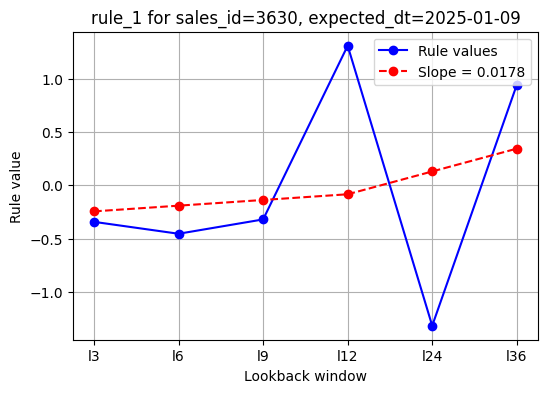

In [36]:
plot_rule_with_slope(rule1_df, sales_id=3630, expected_dt="2025-01-09", rule="rule_1")

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_rule_acceleration(df, sales_id, expected_dt, rule):
    """
    Plot acceleration (second derivative) for a specific sales_id & expected_dt.
    Acceleration = change of consecutive differences between lookback windows.
    X-axis uses clean labels like l0_l3, l3_l6, ...
    """
    # Select row
    row = df[(df['sales_id'] == sales_id) & (df['expected_dt'] == expected_dt)]
    if row.empty:
        print(f"No record found for sales_id={sales_id}, expected_dt={expected_dt}")
        return
    row = row.iloc[0]

    # Extract difference columns for the rule
    pattern = f"^{rule}_l\\d+_l\\d+$"
    diff_cols = [c for c in df.columns if pd.Series(c).str.match(pattern).any()]
    if len(diff_cols) < 2:
        print(f"Not enough difference columns to compute acceleration for {rule}")
        return

    # Sort columns by starting period
    def get_start_period(col):
        parts = col.split('_l')
        return int(parts[1])
    diff_cols = sorted(diff_cols, key=get_start_period)

    # Extract values as numeric
    values = pd.to_numeric(row[diff_cols], errors='coerce').values
    mask = ~np.isnan(values)
    diff_cols, values = np.array(diff_cols)[mask], values[mask]

    if len(values) < 2:
        print("Not enough valid points to compute acceleration.")
        return

    # Compute acceleration
    acceleration = np.diff(values)

    # X-axis labels: clean format l0_l3, l3_l6, ...
    labels = [f"l{col.split('_l')[1]}_l{col.split('_l')[2]}" for col in diff_cols[1:]]

    # Plot
    plt.figure(figsize=(6, 4))
    plt.plot(labels, acceleration, "ro--", markerfacecolor="red", label="Acceleration")
    plt.title(f"Acceleration of {rule} for sales_id={sales_id}, expected_dt={expected_dt}")
    plt.xlabel("Difference window")
    plt.ylabel("Acceleration (change of differences)")
    plt.grid(True)
    plt.legend()
    plt.show()


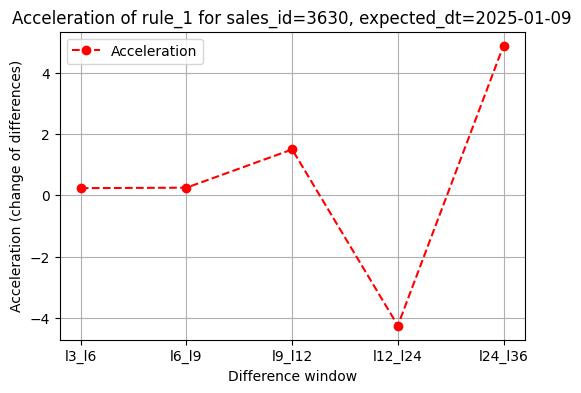

In [56]:
plot_rule_acceleration(diff_rule1_df, sales_id=3630, expected_dt="2025-01-09", rule="rule_1")

In [58]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import re

def compute_all_rule_slopes(df, id_cols=["sales_id", "expected_dt"]):
    """
    Compute slopes for all rules across lookback windows for each key (sales_id + expected_dt).
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing rule columns (e.g., rule_1_l3, rule_2_l6, ...) and id_cols.
    id_cols : list
        Columns that identify each row (default: ["sales_id", "expected_dt"]).
        
    Returns
    -------
    pd.DataFrame
        DataFrame with id_cols + slope columns for each rule (e.g., rule_1_slope, rule_2_slope, ...).
    """
    # Identify all rules by prefix
    rule_cols = [c for c in df.columns if re.search(r'_l\d+$', c)]
    rules = sorted(set([re.match(r'(.*)_l\d+$', c).group(1) for c in rule_cols]))
    
    result = df[id_cols].copy()
    
    for rule in rules:
        # Extract columns for this rule
        pattern = f"^{rule}_l\\d+$"
        cols = [c for c in df.columns if re.match(pattern, c)]
        if not cols:
            continue
        
        # Sort by numeric suffix
        periods = [int(c.split('_l')[-1]) for c in cols]
        sorted_idx = np.argsort(periods)
        cols_sorted = np.array(cols)[sorted_idx]
        periods_sorted = np.array(periods)[sorted_idx].reshape(-1, 1)
        
        # Compute slope for each row
        slopes = []
        for _, row in df.iterrows():
            values = pd.to_numeric(row[cols_sorted], errors='coerce').values
            mask = ~np.isnan(values)
            if mask.sum() < 2:
                slopes.append(np.nan)
            else:
                model = LinearRegression()
                model.fit(periods_sorted[mask], values[mask])
                slopes.append(model.coef_[0])
        
        result[f"{rule}_slope"] = slopes
    
    return result


In [60]:
all_slopes_df = compute_all_rule_slopes(train_all_df)
all_slopes_df

,sales_id,expected_dt,rule_1_slope,rule_10_slope,rule_2_slope,rule_3_slope,rule_4_slope,rule_5_slope,rule_6_slope,rule_7_slope,rule_8_slope,rule_9_slope
0,3630,2025-01-09,0.017811,0.010993,-0.039422,-0.034731,0.014106,-0.030598,-0.041254,-0.054884,-0.026654,-0.011852
1,5986,2024-09-11,0.021654,-0.054184,0.027074,-0.009863,0.018922,-0.040849,-0.031391,0.020309,-0.003293,0.018163
2,7036,2025-05-28,0.009034,-0.055345,-0.029135,0.025303,0.054213,-0.005796,0.022003,-0.006746,0.016314,0.016132
3,628,2025-01-09,-0.060297,0.016169,-0.045575,-0.002646,0.009336,-0.000859,0.065245,-0.017973,-0.019045,-0.014386
4,6352,2024-11-30,0.055360,0.034601,-0.012225,0.031976,-0.007236,0.001632,0.073657,0.007804,-0.041155,-0.007768
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,-0.004984,0.052039,-0.051408,0.031281,-0.007328,0.039431,-0.014925,0.049465,-0.035858,0.025499
7996,5428,2024-12-16,-0.030010,-0.026640,0.064424,-0.034823,0.018692,0.005648,0.064939,-0.062776,0.015788,0.021076
7997,5860,2025-02-21,-0.041204,0.007686,0.007358,0.009477,-0.032526,-0.000784,0.031836,0.018618,-0.052890,-0.035346
7998,5684,2025-05-12,0.026398,-0.043478,0.046381,-0.010448,0.027683,0.062405,0.055191,0.088902,-0.020744,0.005398


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_slope_by_fraud_list(df, slope_col="rule_1_slope", true_fraud_list=[]):
    """
    Compare slope distributions between fraud and non-fraud using a list of fraudulent sales_id.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing slope features and 'sales_id'.
    slope_col : str
        Column name for the slope feature.
    true_fraud_list : list
        List of sales_id that are fraudulent.
    """
    df_plot = df.copy()
    df_plot['fraud_flag'] = df_plot['sales_id'].isin(true_fraud_list).astype(int)
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='fraud_flag', y=slope_col, data=df_plot)
    sns.swarmplot(x='fraud_flag', y=slope_col, data=df_plot, color=".25")
    plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.title(f"{slope_col} Distribution by Fraud Status")
    plt.ylabel("Slope")
    plt.xlabel("Fraud Status")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()


In [ ]:
plot_slope_by_fraud_list(all_slopes_df, slope_col="rule_1_slope", true_fraud_list=true_fraud_list)

KeyboardInterrupt: 